In [1]:
import os 
import pandas as pd 
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt 

from assocplots.manhattan import *


In [7]:
CM = 1/2.54 # centimeters in inches

def miamiplot_graph(piQTL, GWAS, title, label_1, label_2):
    f, axes = plt.subplots(figsize=(4,3), dpi=300)
    manhattan(piQTL['p-value'], piQTL['position'], piQTL['CHR'], '',
    p2=GWAS['p-value'], pos2=GWAS['position'], chr2=GWAS['CHR'], label2='',
    plot_type='inverted',
    chrs_plot=None,
    chrs_names=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', 'MT'],
    cut = 0,
    title=f'{title.replace("_",":")}\nTop: {label_1}\nBottom: {label_2}',
    top1=10,
    top2=10,
    xlabel='Genomic Position',
    ylabel='-log10(p-value)',
    lines=[4],
    lines_colors=['black'],
    lines_styles=['--', '--'],
    lines_widths =[0.2, 0.2],
    scaling = '-log10')
    
    f.savefig(f'../../../figures/figure_2/piQTL_miami_{title}_{label_1.split(", ")[0]}_vs_{label_2.split(", ")[0]}_LD050.eps', dpi=300)  # ToDo: add folder path
    # f.savefig(f'../../../figures/figure_2/piQTL_miami_{title}_{label_1.split(", ")[0]}_vs_{label_2.split(", ")[0]}_LD050.pdf', dpi=300)  # ToDo: add folder path

In [4]:
snps_annotations = pd.read_csv('../../../data/genotype_information/snps_annotations_genome-version-3-64-1_with_gene_annotations_plus_LD_block_definition.txt')
snps_annotations['CHR'] = [int(snps_annotations['chrom'][idx].replace('MT','17').replace('CHR_', '')) for idx in snps_annotations.index ]

In [14]:
## Remove noPPI_reference + FDR filter (0.05)

def get_PPI_spe_SNPs(idx, piQTLs_PPI_specific_ublocks_to_mask):
    PPI = piQTLs_PPI_specific_ublocks_to_mask['PPI'][idx]
    ublock = piQTLs_PPI_specific_ublocks_to_mask['LD_b075'][idx]

    PPI_SNPs = []
    for SNP in ublock.split('_') :
        PPI_SNPs.append(f'{PPI}_{SNP}')
    return ','.join(PPI_SNPs)

In [15]:
## QTL media (SD only and PPI specific) 
f = open('../../../data/masking_tables/QTL_masked_hits.txt')
piQTLs_untagged_ublocks_to_mask = [ line.strip() for line in f.readlines() ]
f.close()

all_SNPs_to_mask = []
for ublock in piQTLs_untagged_ublocks_to_mask: 
    if '_' not in ublock :
        SNP = ublock
        all_SNPs_to_mask.append(int(SNP))
    else : 
        SNPs = ublock.split('_')
        for SNP in SNPs:
            all_SNPs_to_mask.append(int(SNP))

piQTLs_PPI_specific_ublocks_to_mask = pd.read_csv('../../../data/masking_tables/QTL_media_PPI-specific_all_hits.csv')
piQTLs_PPI_specific_SNPs_to_mask = []
for idx in piQTLs_PPI_specific_ublocks_to_mask.index:
    PPI_SNPs = get_PPI_spe_SNPs(idx, piQTLs_PPI_specific_ublocks_to_mask) 
    for SNP in PPI_SNPs.split(','):
        piQTLs_PPI_specific_SNPs_to_mask.append(SNP)

In [16]:
eqtl_matrix_results = pd.read_csv('../../../results/04_eQTL_matrix/piQTL_june2024_pval_results.txt', sep='\t')

<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_992215/937701550.py:12: SyntaxWarning: invalid escape sequence '\D'
  miamiplot_graph(Drug1, noDrug, PPI, 'Fluconazole, $\Delta$(MTX+, MTX-)', 'NoDrug, $\Delta$(MTX+, MTX-)')
/tmp/ipykernel_992215/937701550.py:12: SyntaxWarning: invalid escape sequence '\D'
  miamiplot_graph(Drug1, noDrug, PPI, 'Fluconazole, $\Delta$(MTX+, MTX-)', 'NoDrug, $\Delta$(MTX+, MTX-)')
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/assocplots/manhattan.py:125: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-k" (-> color='k'). The keyword argument will take precedence.
  plt.plot([shift[-1], shift[-1]], [0, 1000], '-k', lw=0.5, color='lightgray')
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/ass

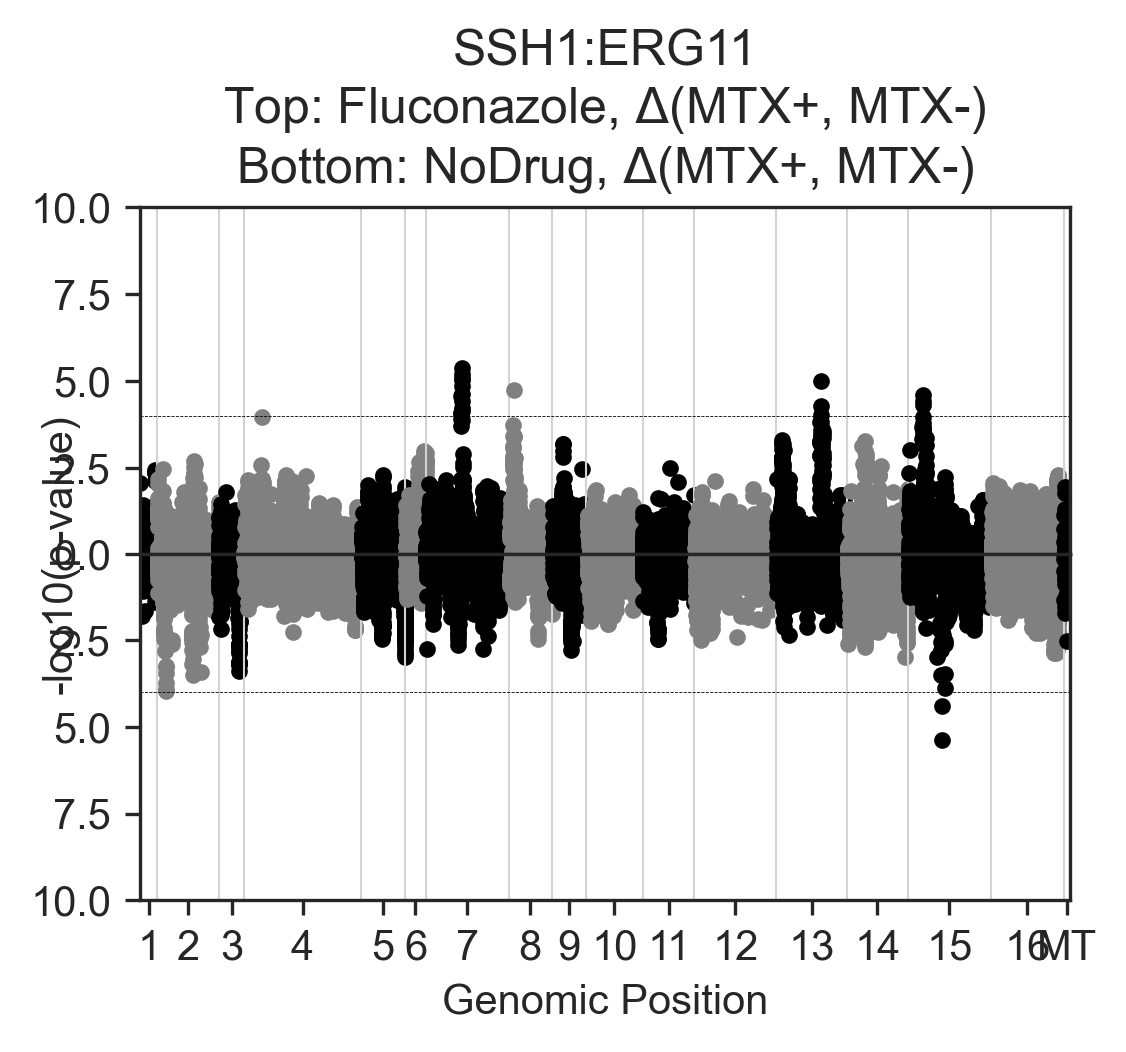

In [17]:
PPI = 'SSH1_ERG11'
DRUG = 'Fluconazole'

CDT = f'{PPI} under {DRUG}' 
Drug1 = eqtl_matrix_results[eqtl_matrix_results['gene'].str.contains(f'{PPI}_MTX_{DRUG}')].merge(snps_annotations, on='SNP')
noDrug = eqtl_matrix_results[eqtl_matrix_results['gene'].str.contains(f'{PPI}_MTX_noDrug')].merge(snps_annotations, on='SNP')

Drug1 = Drug1[~Drug1['SNP'].isin(all_SNPs_to_mask)].reset_index(drop=True)
noDrug = noDrug[~noDrug['SNP'].isin(all_SNPs_to_mask)].reset_index(drop=True)

sns.set_style('ticks')
miamiplot_graph(Drug1, noDrug, PPI, 'Fluconazole, $\Delta$(MTX+, MTX-)', 'NoDrug, $\Delta$(MTX+, MTX-)')

<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_992215/3167342376.py:12: SyntaxWarning: invalid escape sequence '\D'
  miamiplot_graph(Drug1, noDrug, PPI, 'Metformin, $\Delta$(MTX+, MTX-)', 'NoDrug, $\Delta$(MTX+, MTX-)')
/tmp/ipykernel_992215/3167342376.py:12: SyntaxWarning: invalid escape sequence '\D'
  miamiplot_graph(Drug1, noDrug, PPI, 'Metformin, $\Delta$(MTX+, MTX-)', 'NoDrug, $\Delta$(MTX+, MTX-)')
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/assocplots/manhattan.py:125: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-k" (-> color='k'). The keyword argument will take precedence.
  plt.plot([shift[-1], shift[-1]], [0, 1000], '-k', lw=0.5, color='lightgray')
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/assoc

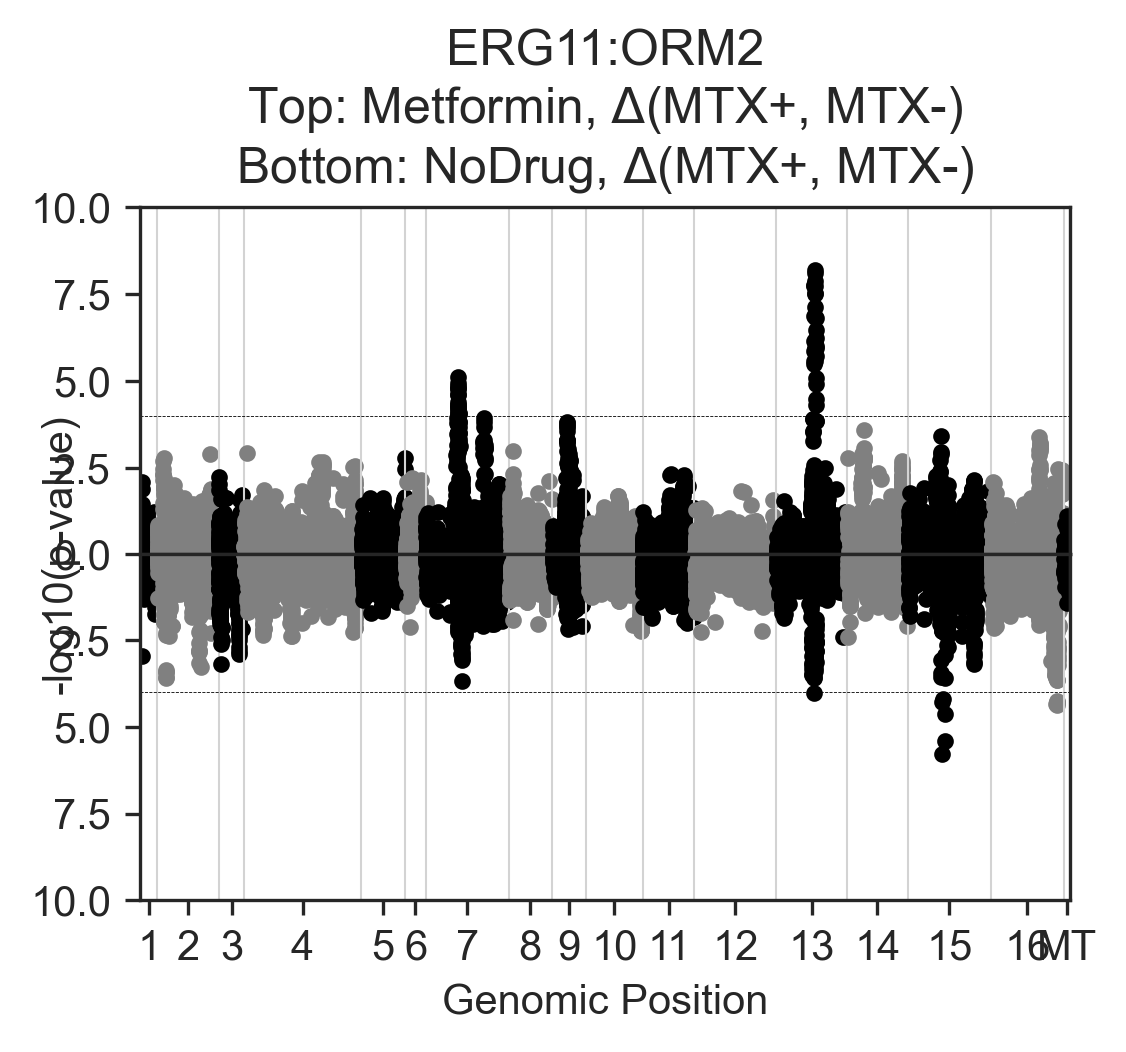

In [18]:
PPI = 'ERG11_ORM2'
DRUG = 'Metformin'

CDT = f'{PPI} under {DRUG}' 
Drug1 = eqtl_matrix_results[eqtl_matrix_results['gene'].str.contains(f'{PPI}_MTX_{DRUG}')].merge(snps_annotations, on='SNP')
noDrug = eqtl_matrix_results[eqtl_matrix_results['gene'].str.contains(f'{PPI}_MTX_noDrug')].merge(snps_annotations, on='SNP')

Drug1 = Drug1[~Drug1['SNP'].isin(all_SNPs_to_mask)].reset_index(drop=True)
noDrug = noDrug[~noDrug['SNP'].isin(all_SNPs_to_mask)].reset_index(drop=True)

sns.set_style('ticks')
miamiplot_graph(Drug1, noDrug, PPI, 'Metformin, $\Delta$(MTX+, MTX-)', 'NoDrug, $\Delta$(MTX+, MTX-)')